# Realtor Dataset – Exploratory Data Analysis

This notebook documents the EDA performed on the Realtor real-estate dataset.

**Goal:** understand data quality, distributions, missing values, outliers and relationships between variables before building a clustering model.

### Load the dataset

We import the required libraries and load the Realtor dataset into a pandas DataFrame.

We also inspect the number of rows and columns and display the first few rows to verify that the dataset has been loaded correctly.

### Data types and structure

We inspect the structure of the dataset and the data types of each column.

This helps us distinguish between numerical and categorical features and identify columns that may require special handling.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2226382 entries, 0 to 2226381
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   brokered_by     float64
 1   status          str    
 2   price           float64
 3   bed             float64
 4   bath            float64
 5   acre_lot        float64
 6   street          float64
 7   city            str    
 8   state           str    
 9   zip_code        float64
 10  house_size      float64
 11  prev_sold_date  str    
dtypes: float64(8), str(4)
memory usage: 269.9 MB


### Load and inspect the dataset

We import the required libraries and load the Realtor dataset into a pandas DataFrame.

We first check the size of the dataset and display the first rows to verify that the data has been loaded correctly.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

df = pd.read_csv("data/realtor-data.csv")

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
df.head()

Rows: 2,226,382
Columns: 12


,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
0,103378.0,for_sale,105000.0,3.0,2.0,0.12,1962661.0,Adjuntas,Puerto Rico,601.0,920.0,NaN
1,52707.0,for_sale,80000.0,4.0,2.0,0.08,1902874.0,Adjuntas,Puerto Rico,601.0,1527.0,NaN
2,103379.0,for_sale,67000.0,2.0,1.0,0.15,1404990.0,Juana Diaz,Puerto Rico,795.0,748.0,NaN
3,31239.0,for_sale,145000.0,4.0,2.0,0.10,1947675.0,Ponce,Puerto Rico,731.0,1800.0,NaN
4,34632.0,for_sale,65000.0,6.0,2.0,0.05,331151.0,Mayaguez,Puerto Rico,680.0,NaN,NaN


## 1. Dataset overview

The dataset contains information about properties, including price, number of bedrooms and bathrooms, lot size, house size and geographic information.

## 2. Missing values

A large part of the dataset contains missing values. Instead of immediately removing rows, we first measure the missingness and later decide how each feature should be handled.

### Data types and structure

We inspect the structure and data types of the dataset.

This helps us identify which variables are numerical and which are categorical before continuing with the analysis.

In [7]:
df.info()
print("\nData types:")
print(df.dtypes)

<class 'pandas.DataFrame'>
RangeIndex: 2226382 entries, 0 to 2226381
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   brokered_by     float64
 1   status          str    
 2   price           float64
 3   bed             float64
 4   bath            float64
 5   acre_lot        float64
 6   street          float64
 7   city            str    
 8   state           str    
 9   zip_code        float64
 10  house_size      float64
 11  prev_sold_date  str    
dtypes: float64(8), str(4)
memory usage: 269.9 MB

Data types:
brokered_by       float64
status                str
price             float64
bed               float64
bath              float64
acre_lot          float64
street            float64
city                  str
state                 str
zip_code          float64
house_size        float64
prev_sold_date        str
dtype: object


### Missing-value analysis

We calculate both the number and percentage of missing values in each column.

This helps us identify which features have substantial missingness and need special handling during preprocessing.

In [9]:
missing = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
)

missing_pct = (missing / len(df) * 100).round(2)

missing_table = pd.DataFrame({
    "missing": missing,
    "missing_pct": missing_pct,
})

missing_table

,missing,missing_pct
prev_sold_date,734297,32.98
house_size,568484,25.53
bath,511771,22.99
bed,481317,21.62
acre_lot,325589,14.62
street,10866,0.49
brokered_by,4533,0.20
price,1541,0.07
city,1407,0.06
zip_code,299,0.01


## 3. Duplicates

We check whether the dataset contains completely duplicated rows.

### Duplicate rows

We count completely duplicated rows to determine whether identical observations are present in the dataset.

In [10]:
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates:,}")

Duplicate rows: 0


## 4. Categorical distributions

`status` contains the property's current status. We inspect its distribution because a heavily imbalanced categorical variable may not be suitable as a primary clustering feature.

### Status distribution

We inspect the number and percentage of properties in each status category.

This shows how the categorical variable is distributed and helps determine whether it should be used directly in the clustering model.

In [11]:
print(df["status"].value_counts(dropna=False))
print()
print((df["status"].value_counts(normalize=True, dropna=False) * 100).round(2))

status
for_sale          1389306
sold               812009
ready_to_build      25067
Name: count, dtype: int64

status
for_sale          62.40
sold              36.47
ready_to_build     1.13
Name: proportion, dtype: float64


## 5. Cardinality

High-cardinality variables such as street, city and ZIP code need special consideration. Using all of them directly in a first K-Means model would create a very large feature space and could make the clusters difficult to interpret.

### Unique values

We count the number of unique values in each column.

This helps identify high-cardinality variables such as `street`, `city` and `zip_code`, which are not included in the first numerical clustering model.

In [29]:
unique_counts = (
    df.nunique(dropna=True)
      .sort_values(ascending=False)
)

unique_counts

street            2001358
brokered_by        110143
price              102137
zip_code            30334
city                20098
acre_lot            16057
prev_sold_date      14954
house_size          12061
bed                    99
bath                   86
state                  55
status                  3
dtype: int64

## 6. Numeric distributions

We inspect descriptive statistics and quantiles to identify skewness and extreme values.

### Descriptive statistics

We inspect summary statistics and upper percentiles for the main numerical features.

The high percentiles help us identify skewed distributions and potentially extreme observations.

In [13]:
numeric_columns = [
    "price",
    "bed",
    "bath",
    "acre_lot",
    "house_size",
]

df[numeric_columns].describe(percentiles=[0.5, 0.9, 0.95, 0.99, 0.995, 0.999]).T

,count,mean,std,min,50%,90%,95%,99%,99.5%,99.9%,max
price,2224841.0,524195.519291,2.138893e+06,0.0,325000.00,949000.0,1495000.00,3899000.00,5.800000e+06,1.450000e+07,2.147484e+09
bed,1745065.0,3.275841,1.567274e+00,1.0,3.00,4.0,5.00,7.00,8.000000e+00,1.400000e+01,4.730000e+02
bath,1714611.0,2.496440,1.652573e+00,1.0,2.00,4.0,4.00,6.00,8.000000e+00,1.200000e+01,8.300000e+02
acre_lot,1900793.0,15.223027,7.628238e+02,0.0,0.26,5.0,14.02,98.00,1.734804e+02,8.966976e+02,1.000000e+05
house_size,1657898.0,2714.471335,8.081635e+05,4.0,1760.00,3279.0,4008.00,6439.03,8.000000e+03,1.451293e+04,1.040400e+09


### Numerical distributions

We visualize the main numerical features using histograms.

The distributions show strong right-skewness in several variables, which is important when preparing the data for clustering.

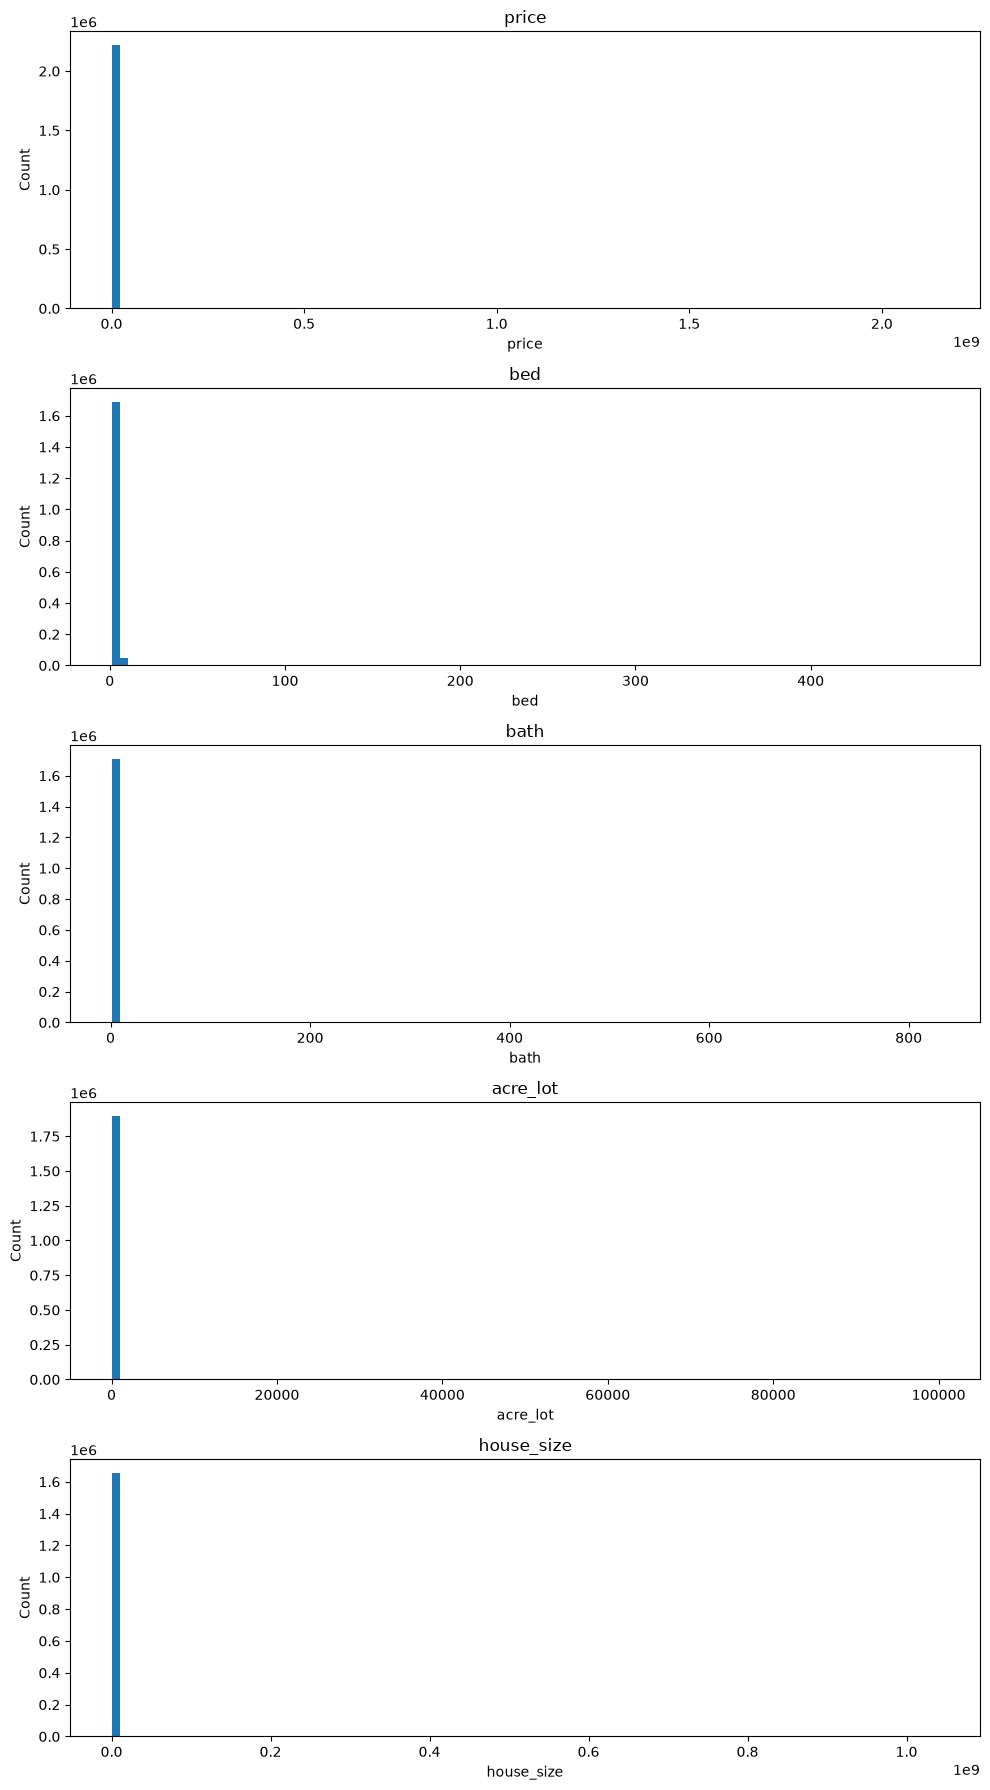

In [14]:
fig, axes = plt.subplots(5, 1, figsize=(10, 18))

for ax, column in zip(axes, numeric_columns):
    ax.hist(df[column].dropna(), bins=100)
    ax.set_title(column)
    ax.set_xlabel(column)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

## 7. Outlier analysis

The raw dataset contains clearly suspicious extreme values. Examples include extremely high numbers of bedrooms or bathrooms, very large house sizes, very large lot sizes and non-positive prices.

These values are investigated before clustering because K-Means is distance-based and can be strongly affected by extreme observations.

### Extreme-value checks

We count observations above selected thresholds for the main numerical features.

This gives us a quantitative overview of extreme observations before defining the final cleaning rules.

In [31]:
extreme_counts = {
    "bed > 20": (df["bed"] > 20).sum(),
    "bath > 20": (df["bath"] > 20).sum(),
    "house_size > 20000": (df["house_size"] > 20_000).sum(),
    "acre_lot > 1000": (df["acre_lot"] > 1_000).sum(),
    "price <= 0": (df["price"] <= 0).sum(),
    "price > 100M": (df["price"] > 100_000_000).sum(),
}

extreme_counts

{'bed > 20': np.int64(725),
 'bath > 20': np.int64(401),
 'house_size > 20000': np.int64(754),
 'acre_lot > 1000': np.int64(1719),
 'price <= 0': np.int64(280),
 'price > 100M': np.int64(24)}

In [32]:
clean_df = df.copy()

before = len(clean_df)

clean_df = clean_df.loc[
    (clean_df["price"] > 0)
    & (clean_df["bed"].isna() | (clean_df["bed"] <= 20))
    & (clean_df["bath"].isna() | (clean_df["bath"] <= 20))
    & (clean_df["house_size"].isna() | (clean_df["house_size"] <= 20_000))
    & (clean_df["acre_lot"].isna() | (clean_df["acre_lot"] <= 1_000))
].copy()

after = len(clean_df)

print(f"Rows before cleaning: {before:,}")
print(f"Rows after cleaning:  {after:,}")
print(f"Rows removed:         {before - after:,}")
print(f"Percentage removed:   {(before - after) / before * 100:.2f}%")

Rows before cleaning: 2,226,382
Rows after cleaning:  2,221,453
Rows removed:         4,929
Percentage removed:   0.22%


### Extreme-value checks

We count observations above selected thresholds for the main numerical features.

This gives us a quantitative overview of extreme observations before defining the final cleaning rules.

In [30]:
outlier_checks = {
    "bed > 10": (df["bed"] > 10).sum(),
    "bath > 10": (df["bath"] > 10).sum(),
    "acre_lot > 100": (df["acre_lot"] > 100).sum(),
    "house_size > 10000": (df["house_size"] > 10000).sum(),
    "price > 10000000": (df["price"] > 10000000).sum(),
    "price <= 0": (df["price"] <= 0).sum(),
}

pd.Series(outlier_checks, name="count")

bed > 10               3729
bath > 10              2300
acre_lot > 100        18166
house_size > 10000     4213
price > 10000000       3996
price <= 0              280
Name: count, dtype: int64

In [33]:
clean_df.isna().sum().sort_values(ascending=False)

prev_sold_date    731322
house_size        566963
bath              509692
bed               479921
acre_lot          324741
street             10758
brokered_by         4524
city                1384
zip_code             291
state                  8
price                  0
status                 0
dtype: int64

### Chosen cleaning thresholds

For the clustering preparation we remove:

- `price <= 0`
- `bed > 20`
- `bath > 20`
- `house_size > 20,000`
- `acre_lot > 1,000`

We do not automatically remove very expensive properties solely because their price is high; a high price can represent a real property rather than a data error.

## 8. Correlation analysis

We inspect correlations between the main numeric property variables. This helps us understand relationships and potential redundancy before selecting clustering features.

### Correlations

We calculate pairwise correlations between the main numerical features.

This helps us understand relationships between variables before selecting the features for clustering.

In [16]:
corr = df[numeric_columns].corr()

corr

,price,bed,bath,acre_lot,house_size
price,1.000000,0.114761,0.178391,0.016166,0.000254
bed,0.114761,1.000000,0.611708,-0.000021,0.189682
bath,0.178391,0.611708,1.000000,-0.000962,0.223767
acre_lot,0.016166,-0.000021,-0.000962,1.000000,0.000987
house_size,0.000254,0.189682,0.223767,0.000987,1.000000


### Correlation visualization

We visualize the correlation matrix to make the relationships between the numerical features easier to compare.

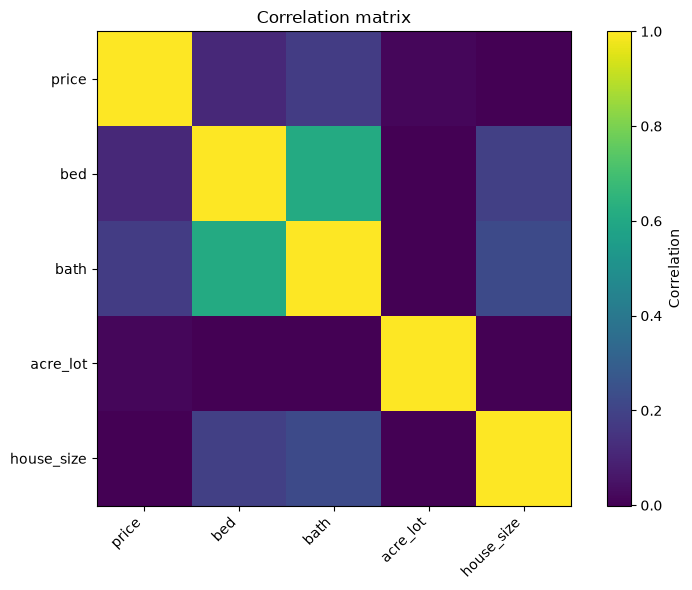

In [17]:
plt.figure(figsize=(8, 6))
plt.imshow(corr, interpolation="nearest")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar(label="Correlation")
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

## 9. Feature selection for clustering

The first clustering model uses:

- `price`
- `bed`
- `bath`
- `acre_lot`
- `house_size`

These variables describe the property itself and its market value.

`street` and `brokered_by` are treated as identifier-like variables and are excluded.

`city` and `zip_code` have high cardinality and are excluded from the first numerical K-Means model. They can instead be used later to analyse the geographic composition of the resulting clusters.

`prev_sold_date` has substantial missingness, so it is not included in the primary clustering feature set. `status` is categorical and strongly imbalanced, so it is also better suited for post-clustering analysis than as a primary K-Means feature.

## 10. EDA conclusions

The EDA shows that:

1. The dataset is very large, with more than 2.2 million observations.
2. Several variables contain substantial missingness.
3. `price`, `acre_lot` and `house_size` are strongly right-skewed.
4. The raw data contains extreme and likely invalid observations.
5. `bed`, `bath` and `house_size` have clear positive relationships.
6. High-cardinality geographic and identifier-like variables should not be included directly in the first K-Means model.
7. The selected numerical features require missing-value handling, log transformation for strongly skewed variables and standardisation before K-Means.

The next step is therefore clustering preparation and selection of an appropriate number of clusters.

## 11. Preparing the data for clustering

Based on the EDA, the first clustering model will use five numerical features:

- `price`
- `bed`
- `bath`
- `acre_lot`
- `house_size`

The preparation below removes clearly invalid/extreme observations, fills missing numerical values with the median, log-transforms strongly right-skewed variables and standardizes all features.

The transformations are performed in the notebook because this notebook contains the analysis and model-training workflow.

### Select and clean clustering features

We create a separate DataFrame containing only the selected clustering features.

The same cleaning thresholds identified during the EDA are applied before continuing with imputation and transformation.

In [18]:
CLUSTER_FEATURES = [
    "price",
    "bed",
    "bath",
    "acre_lot",
    "house_size",
]

LOG_FEATURES = [
    "price",
    "acre_lot",
    "house_size",
]

cluster_df = df.loc[:, CLUSTER_FEATURES].copy()

original_rows = len(cluster_df)

# Remove invalid/extreme observations identified during EDA
cluster_df = cluster_df.loc[
    (cluster_df["price"] > 0)
    & (cluster_df["bed"].isna() | (cluster_df["bed"] <= 20))
    & (cluster_df["bath"].isna() | (cluster_df["bath"] <= 20))
    & (cluster_df["house_size"].isna() | (cluster_df["house_size"] <= 20_000))
    & (cluster_df["acre_lot"].isna() | (cluster_df["acre_lot"] <= 1_000))
].copy()

print(f"Original rows: {original_rows:,}")
print(f"Rows after cleaning: {len(cluster_df):,}")
print(f"Removed: {original_rows - len(cluster_df):,}")

Original rows: 2,226,382
Rows after cleaning: 2,221,453
Removed: 4,929


### Missing values

Dropping every row with a missing clustering feature would remove a substantial part of the dataset. Instead, missing numerical values are replaced by the median of their respective feature.

### Median imputation

We replace missing values in the selected numerical features with their respective medians.

Using the median reduces the influence of extreme values compared with using the mean.

In [19]:
cluster_df = cluster_df.fillna(
    cluster_df.median(numeric_only=True)
)

print("Missing values after median imputation:")
print(cluster_df.isna().sum())

Missing values after median imputation:
price         0
bed           0
bath          0
acre_lot      0
house_size    0
dtype: int64


### Log transformation

`price`, `acre_lot` and `house_size` showed strong right-skewness during EDA. `log1p` reduces the influence of very large values while preserving the observations.

### Apply log transformation

We apply `log1p` to the strongly right-skewed features identified during the EDA.

This reduces the influence of very large values before standardisation and clustering.

In [20]:
for column in LOG_FEATURES:
    cluster_df[column] = np.log1p(cluster_df[column])

cluster_df[CLUSTER_FEATURES].describe().T

,count,mean,std,min,25%,50%,75%,max
price,2221453.0,12.545050,1.154743,0.693147,12.013707,12.691584,13.217675,21.487563
bed,2221453.0,3.203616,1.049969,1.000000,3.000000,3.000000,4.000000,20.000000
bath,2221453.0,2.373139,1.041594,1.000000,2.000000,2.000000,3.000000,20.000000
acre_lot,2221453.0,0.565028,0.861559,0.000000,0.157004,0.231112,0.518794,6.908755
house_size,2221453.0,7.485100,0.415886,1.609438,7.283448,7.473069,7.668561,9.903538


### Standardisation

K-Means is distance-based. Standardisation prevents variables with larger numerical scales from dominating the distance calculation.

### Apply standardisation

We standardize all selected clustering features using `StandardScaler`.

This puts the features on comparable scales so that no single feature dominates the distance calculations used by K-Means.

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(cluster_df[CLUSTER_FEATURES])

X = pd.DataFrame(
    X,
    columns=CLUSTER_FEATURES,
    index=cluster_df.index,
)

print("Means:")
print(X.mean().round(6))

print("\nStandard deviations:")
print(X.std().round(6))

print("\nShape:")
print(X.shape)

Means:
price        -0.0
bed           0.0
bath         -0.0
acre_lot      0.0
house_size   -0.0
dtype: float64

Standard deviations:
price         1.0
bed           1.0
bath          1.0
acre_lot      1.0
house_size    1.0
dtype: float64

Shape:
(2221453, 5)


## 12. Selecting the number of clusters

K-Means requires us to choose the number of clusters, `k`.

We test several candidate values rather than choosing `k` arbitrarily. Because the dataset contains more than two million observations, a representative sample is used for this model-selection step.

We use:

- **Inertia** for the elbow method.
- **Silhouette score** to evaluate cluster separation.

### Test candidate values of `k`

We test values of `k` from 2 to 10 using a representative sample of 100,000 observations.

For each value, we calculate inertia and silhouette score to compare the clustering results.

In [22]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sample_size = 100_000

X_sample = X.sample(
    n=sample_size,
    random_state=42,
)

k_values = range(2, 11)

results = []

for k in k_values:
    print(f"Testing k={k}...")

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,
    )

    labels = model.fit_predict(X_sample)

    inertia = model.inertia_

    silhouette = silhouette_score(
        X_sample,
        labels,
        sample_size=20_000,
        random_state=42,
    )

    results.append({
        "k": k,
        "inertia": inertia,
        "silhouette": silhouette,
    })

results = pd.DataFrame(results)

results

Testing k=2...
Testing k=3...
Testing k=4...
Testing k=5...
Testing k=6...
Testing k=7...
Testing k=8...
Testing k=9...
Testing k=10...


,k,inertia,silhouette
0,2,349082.691740,0.326019
1,3,279582.966019,0.353695
2,4,235879.175037,0.249632
3,5,199779.086750,0.286767
4,6,174480.344099,0.283284
5,7,163500.572940,0.255759
6,8,152635.626986,0.257435
7,9,143308.351259,0.252915
8,10,136847.058573,0.238337


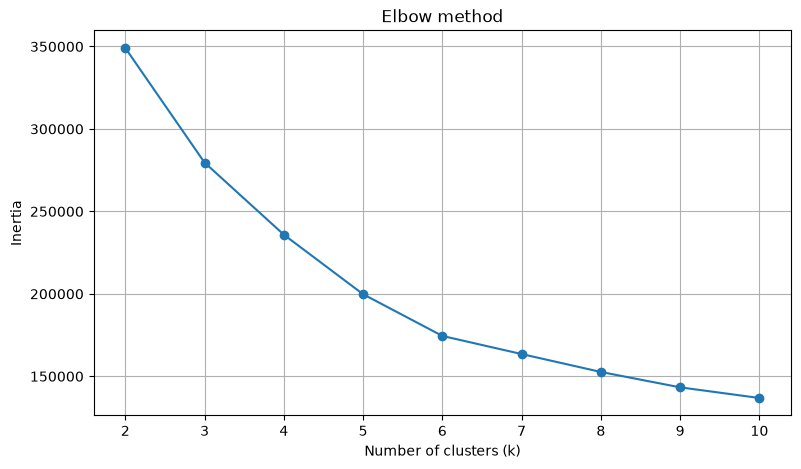

In [23]:
plt.figure(figsize=(9, 5))
plt.plot(results["k"], results["inertia"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow method")
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

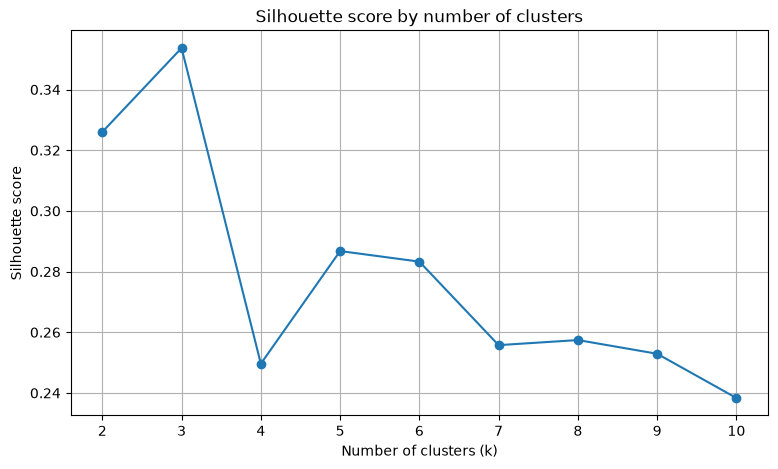

In [24]:
plt.figure(figsize=(9, 5))
plt.plot(results["k"], results["silhouette"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette score by number of clusters")
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

### Choosing `k`

We compare the elbow plot and silhouette scores to select the number of clusters.

The highest silhouette score was obtained with `k=3`, with a score of approximately 0.354. Based on these results, we select three clusters for the final K-Means model.

In [ ]:
# Set this after inspecting the elbow and silhouette results.
# Example:
# SELECTED_K = 4
# Efter att ha jämfört elbow och silhouette väljer vi 3 

SELECTED_K = 3

if SELECTED_K is None:
    print("Set SELECTED_K after reviewing the elbow and silhouette plots.")
else:
    print(f"Selected k: {SELECTED_K}")

Selected k: 3


### Train the final model

We train the final K-Means model using the selected value `k=3` and the complete prepared dataset.

The resulting cluster assignments are stored for further analysis.

### Cluster characteristics

We calculate the median values of the original features for each cluster.

Using the original values makes the clusters easier to interpret in real-world terms such as price, house size, bedrooms, bathrooms and lot size.

In [38]:
if SELECTED_K is not None:
    final_model = KMeans(
        n_clusters=SELECTED_K,
        random_state=42,
        n_init=10,
    )

    cluster_labels = final_model.fit_predict(X)

    cluster_df["cluster"] = cluster_labels

    print("Final model trained.")
    print()
    print("Cluster sizes:")
    print(cluster_df["cluster"].value_counts().sort_index())
else:
    print("Select SELECTED_K first.")

Final model trained.

Cluster sizes:
cluster
0     602825
1    1431304
2     187324
Name: count, dtype: int64


## 14. Analyse the clusters

Cluster interpretation should be performed using the original, untransformed feature values so that the results are understandable in real-world terms.

In [43]:
analysis_df = df.loc[cluster_df.index, CLUSTER_FEATURES].copy()
analysis_df["cluster"] = cluster_df["cluster"]

cluster_summary = (
    analysis_df
    .groupby("cluster")[CLUSTER_FEATURES]
    .median()
    .round(2)
)

print(cluster_summary)

            price  bed  bath  acre_lot  house_size
cluster                                           
0        595000.0  4.0   3.0      0.25      2698.0
1        239900.0  3.0   2.0      0.23      1428.0
2        325000.0  3.0   2.0     13.04      1896.0


## 15. Final conclusions

The EDA established the data-quality issues and informed the clustering feature selection. The clustering workflow then prepares the selected numerical features, tests candidate values of `k`, trains K-Means with the selected value and summarizes the resulting clusters.

The final cluster interpretation should describe the observed differences between groups rather than assigning subjective labels to them.